# Bias Summary Plots by Modality and Emotion

This notebook reads `bias_summary_10folds_biased.xlsx` and creates two grouped bar charts:
1. Statistical Parity (SP) difference by emotion and modality
2. Equal Opportunity (EO) difference by emotion and modality

If the workbook is open in Excel, close it before running the notebook to avoid read errors.

In [13]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    import openpyxl  # noqa: F401
except ImportError as exc:
    raise ImportError(
        'openpyxl is required to read Excel files. Install it with `pip install openpyxl`.'
    ) from exc

sns.set(style="whitegrid", font_scale=1.1)
%matplotlib inline

In [14]:
file_path = Path('bias_summary_10folds_unbiased.xlsx')
if not file_path.exists():
    raise FileNotFoundError(f'Expected file not found: {file_path.resolve()}')

try:
    workbook = pd.ExcelFile(file_path, engine='openpyxl')
except Exception as exc:
    raise RuntimeError(
        'Unable to read the Excel workbook. Close it in Excel and rerun the cell.'
        f' Original error: {exc}'
    ) from exc

print('Workbook sheet names:', workbook.sheet_names)
print()
sheet_name = workbook.sheet_names[0]
print('Reading sheet:', sheet_name)
df = pd.read_excel(workbook, sheet_name=sheet_name, engine='openpyxl')
print('Columns:')
print(df.columns.tolist())
df.head()

Workbook sheet names: ['bias_summary_10folds_unbiased']

Reading sheet: bias_summary_10folds_unbiased
Columns:
['condition', 'n_folds', 'uar_m', 'uar_f', 'uar_diff', 'sp_abs_mean', 'eo_abs_mean', 'f1_m_happy', 'f1_m_angry', 'f1_m_sad', 'f1_m_neutral', 'f1_f_happy', 'f1_f_angry', 'f1_f_sad', 'f1_f_neutral', 'f1_diff_happy', 'f1_diff_angry', 'f1_diff_sad', 'f1_diff_neutral', 'sp_happy', 'sp_angry', 'sp_sad', 'sp_neutral', 'eo_happy', 'eo_angry', 'eo_sad', 'eo_neutral']


,condition,n_folds,uar_m,uar_f,uar_diff,sp_abs_mean,eo_abs_mean,f1_m_happy,f1_m_angry,f1_m_sad,...,f1_diff_sad,f1_diff_neutral,sp_happy,sp_angry,sp_sad,sp_neutral,eo_happy,eo_angry,eo_sad,eo_neutral
0,azz,10,0.5650,0.5756,-0.0105,0.0256,0.0267,0.6209,0.5125,0.4385,...,0.0121,0.0585,-0.0511,0.0178,0.0139,0.0194,0.0323,-0.0315,-0.0213,-0.0217
1,zvz,10,0.4938,0.5215,-0.0278,0.0434,0.1046,0.4058,0.6869,0.4338,...,0.0778,0.1237,0.0865,-0.0798,-0.0070,0.0003,0.1314,-0.1502,0.0223,-0.1146
2,zzl,10,0.6819,0.6409,0.0410,0.0211,0.0410,0.7075,0.7189,0.6535,...,0.0645,0.0576,-0.0296,0.0113,0.0309,-0.0125,0.0960,0.0165,0.0070,0.0447
3,avz,10,0.6335,0.6462,-0.0127,0.0281,0.0320,0.6564,0.6522,0.5079,...,0.0496,0.0485,-0.0561,0.0058,0.0482,0.0021,0.0052,-0.0549,0.0335,-0.0343
4,azl,10,0.7450,0.7339,0.0111,0.0262,0.0260,0.7729,0.7485,0.6603,...,0.0245,0.0033,-0.0525,0.0133,0.0314,0.0078,0.0468,-0.0074,-0.0225,0.0273


In [15]:
emotion_order = ['happy', 'angry', 'sad', 'neutral']

sp_cols = [f'sp_{emotion}' for emotion in emotion_order]
eo_cols = [f'eo_{emotion}' for emotion in emotion_order]

for col in ['condition'] + sp_cols + eo_cols:
    if col not in df.columns:
        raise KeyError(f"Expected column not found in Excel file: {col}")

sp_long = df.melt(
    id_vars=['condition'],
    value_vars=sp_cols,
    var_name='emotion',
    value_name='value',
)
sp_long['emotion'] = sp_long['emotion'].str.replace('sp_', '', regex=False).str.title()
sp_long['bias'] = 'SP'

eo_long = df.melt(
    id_vars=['condition'],
    value_vars=eo_cols,
    var_name='emotion',
    value_name='value',
)
eo_long['emotion'] = eo_long['emotion'].str.replace('eo_', '', regex=False).str.title()
eo_long['bias'] = 'EO'

combined = pd.concat([sp_long, eo_long], ignore_index=True)
combined = combined.rename(columns={'condition': 'modality'})
combined['value'] = pd.to_numeric(combined['value'], errors='coerce')
combined = combined.dropna(subset=['value'])
combined['emotion'] = combined['emotion'].astype(str).str.strip()

print('Detected modalities:', combined['modality'].unique())
print('Detected bias types:', combined['bias'].unique())
combined.head()

Detected modalities: ['azz' 'zvz' 'zzl' 'avz' 'azl' 'zvl' 'avl']
Detected bias types: ['SP' 'EO']


,modality,emotion,value,bias
0,azz,Happy,-0.0511,SP
1,zvz,Happy,0.0865,SP
2,zzl,Happy,-0.0296,SP
3,avz,Happy,-0.0561,SP
4,azl,Happy,-0.0525,SP


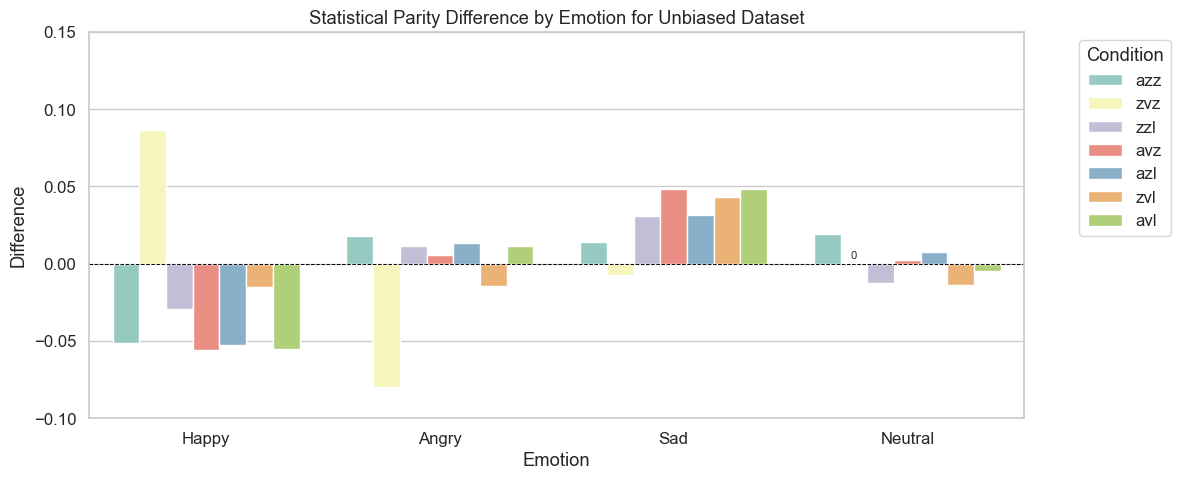

In [16]:
order = ['Happy', 'Angry', 'Sad', 'Neutral']
modality_order = combined['modality'].drop_duplicates().tolist()
palette = sns.color_palette('Set3', n_colors=len(modality_order))

plt.figure(figsize=(12, 5))
plot_data = combined[combined['bias'] == 'SP']
if plot_data.empty:
    plt.text(0.5, 0.5, 'No SP data found.', ha='center', va='center', fontsize=14)
    plt.gca().set_axis_off()
else:
    ax = sns.barplot(
        data=plot_data,
        x='emotion',
        y='value',
        hue='modality',
        order=order,
        hue_order=modality_order,
        palette=palette,
        errorbar=None,
    )
    for container in ax.containers:
        for bar in container:
            if abs(bar.get_height()) < 0.002:
                ax.annotate(
                    '0',
                    (bar.get_x() + bar.get_width() / 2, 0),
                    xytext=(0, 2),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                )
    plt.title('Statistical Parity Difference by Emotion for Unbiased Dataset')
    plt.xlabel('Emotion')
    plt.ylabel('Difference')
    plt.ylim(-0.10, 0.15)
    plt.axhline(0, color='black', linewidth=0.7, linestyle='--')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

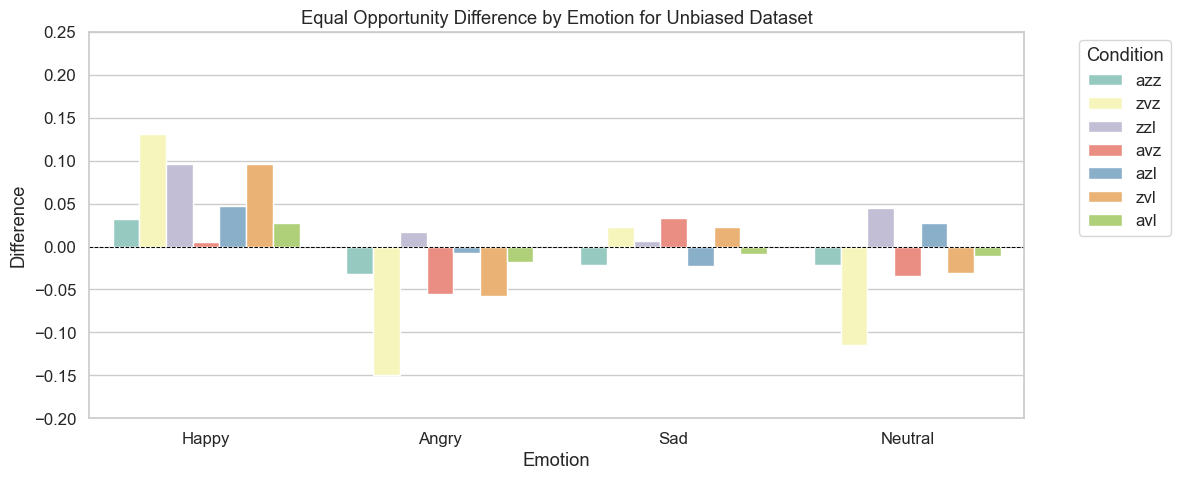

In [17]:
plt.figure(figsize=(12, 5))
plot_data = combined[combined['bias'] == 'EO']
if plot_data.empty:
    plt.text(0.5, 0.5, 'No EO data found.', ha='center', va='center', fontsize=14)
    plt.gca().set_axis_off()
else:
    ax = sns.barplot(
        data=plot_data,
        x='emotion',
        y='value',
        hue='modality',
        order=order,
        hue_order=modality_order,
        palette=palette,
        errorbar=None,
    )
    for container in ax.containers:
        for bar in container:
            if abs(bar.get_height()) < 0.002:
                ax.annotate(
                    '0',
                    (bar.get_x() + bar.get_width() / 2, 0),
                    xytext=(0, 2),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                )
    plt.title('Equal Opportunity Difference by Emotion for Unbiased Dataset')
    plt.xlabel('Emotion')
    plt.ylabel('Difference')
    plt.ylim(-0.20, 0.25)
    plt.axhline(0, color='black', linewidth=0.7, linestyle='--')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

## Save the Plot

If you want to save the figure to a file, uncomment and run the code below.

In [18]:
# fig.savefig('bias_summary_sp_eo_by_emotion.png', dpi=150, bbox_inches='tight')
# print('Saved plot to bias_summary_sp_eo_by_emotion.png')